In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xmf6
from denit import gwf, gwt, plot, utils
linea = 50*chr(0x2015)

In [56]:
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp",
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos
    u_init = os.path.join("remix", "u_init.dat"),
    u_tilde = os.path.join("remix", "u_tilde.dat"),
    u_new = os.path.join("remix", "u_new.out"),
    #
    # Ejecutable REMIX y archivo de entrada
    remix_exe = os.path.join("remix", "bin", "interfaz_remix.exe"),
    remix_input = os.path.join("datos_interfaz_denit_2reacts"),
)
paths["command"] = f"{paths["remix_exe"]} < {paths["remix_input"]}"
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#
print(linea)
print("Generating initial conditions".center(50))
components, species = utils.initial_conditions(paths, comp = True, spec = True)
ncomp = len(components["names"])
print(linea)
#
xmf6.nice_print(paths, "Paths and filenames")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e-0
NT = 5
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.1, 1.0, 1.0 
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Spatial discretization")
#
# Parámetros físicos.
phys = dict(
    perioddata = [(dt, 1, 1.0)], #PERLEN, NSTP, TSMULT
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    inflow = 0.2,  # Specific discharge ($cm s^{-1}$)
    longitudinal_dispersivity = 0.5,
    retardation_factor = 1.0, 
    components = components["names"], # Components names
    source_concentration = components["ext_water"],  # Source concentration (unitless)
    initial_concentration = components["init_conc"], # Initial concentration (unitless)
)
xmf6.nice_print(phys, "Physical parameters")

――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
-> File remix\u_init.dat already exist
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
    mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
    mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
  flow_name = flow
    flow_ws = mf6_gwf_gwt_comp
  tran_name = transport
    tran_ws = mf6_gwf_gwt_comp
     u_init = remix\u_init.dat
    u_tilde = remix\u_tilde.dat
      u_new = remix\u_new.out
  remix_exe = remix\bin\interfaz_remix.exe
remix_input = datos_interfaz_denit_2reacts
    command = remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 1.0
         top = 1.0
        botm = 0.0
――――――――――――――――――――――

Physi

In [57]:
u_tilde = [0 for i in range(0,ncomp)]
s_final = {}

for it in range(1, NT+1):
    ts = it * dt
    print(linea)
    print(f"Step = {it}, time = {ts}d".center(50))
    print(linea)

    for m in range(0, ncomp):
        #
        # - ACTUALIZACION DEL FLUJO CON GWF ---
        #
        # --- Construcción de la simulación de flujo
        o_sim_f = gwf.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación ---
        print(" GWF", end = "")
        o_sim_f.run_simulation(silent=True)
        #
        # - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
        #
        # --- Construcción de la simulación de transporte
        o_sim_t = gwt.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación de transporte ---
        print(f"-GWT: C{m+1}", end= " |")
        o_sim_t.run_simulation(silent=True)
        #
        # --- Obtenemos la concentración calculada por GWT
        u_tilde[m] = utils.get_conc(o_sim_t)
    #
    # --- Guardamos concentraciones en "u_tilde.dat"
    print("\n-> Writting: u_tilde.dat")
    with open(paths["u_tilde"], "w") as f:
        for a in u_tilde:
            f.writelines(" ".join([c for c in a.astype(str)]))
            f.write("\n")
    #
    # ---- Ejecutamos REMIX usando las nuevas concentraciones
    print(f"-> Executing: {paths["command"]}\n")
    ret = os.system(paths["command"])
    print(f"\n-> Error code: {ret}")
    #
    # --- Leemos las concentraciones de las componentes calculadas por REMIX
    print(f"-> Reading: {paths["u_new"]}")
    with open(paths["u_new"], "r") as f:
        lines = f.readlines()
    #
    # Actualizamos las concentraciones para GWT
    key_string = "Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):"
    iccn = utils.find_index(lines, key_string, 2)
    u_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp]]
    phys["initial_concentration"] = u_new

    # Almacenamos las especies calculadas en el diccionario s_final
    key_string = "Concentrations of variable activity species after solving reactive mixing iteration (rows: species, columns: targets):"
    isp = utils.find_index(lines, key_string, 2)
    s_final[ts] = [np.array(l.split(), dtype=float) for l in lines[isp:isp+ncomp+1]]

――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 1, time = 1.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT: C4 | GWF-GWT: C5 | GWF-GWT: C6 | GWF-GWT: C7 |
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 2, time = 2.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT: C4 | GWF-GWT: C5 | GWF-GWT: C6 | GWF-GWT: C7 |
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 3, time = 3.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT:

[[[1.18 1.16 1.14 1.12 1.1  1.08 1.06 1.04 1.02 1.  ]]]


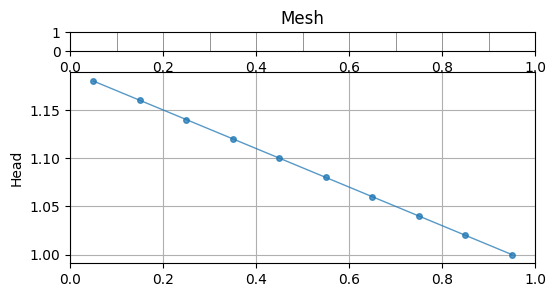

In [58]:
o_gwf, head, x, y, z = utils.get_head(o_sim_f)
print(head)
plot.show_f(o_gwf, head, x, y, z)

In [59]:
# --- Leemos las concentraciones de las especies del EXCEL
denit_excel = pd.read_excel("remix/denit_2reacts_corregido.xlsx", 
                            sheet_name = "results", usecols=range(0,11), 
                            skiprows=4, header=None)
spe_names = [c.strip() for c in denit_excel.iloc[2:10,0]]
idx = 2
nspec = 8
skip = 15
times = ["0.00d", "0.01d", "0.02d", "0.10d", "1.00d", "5.00d"]
ranges = [(idx + i*skip, idx + i*skip + nspec) for i in range(0, 6)]
print(ranges)

s_excel = []
for it in range(0,6):
    iini = ranges[it][0]
    ifin = ranges[it][1]
    s_excel.append(denit_excel.iloc[iini:ifin, 1:].to_numpy(dtype=float))

[(2, 10), (17, 25), (32, 40), (47, 55), (62, 70), (77, 85)]


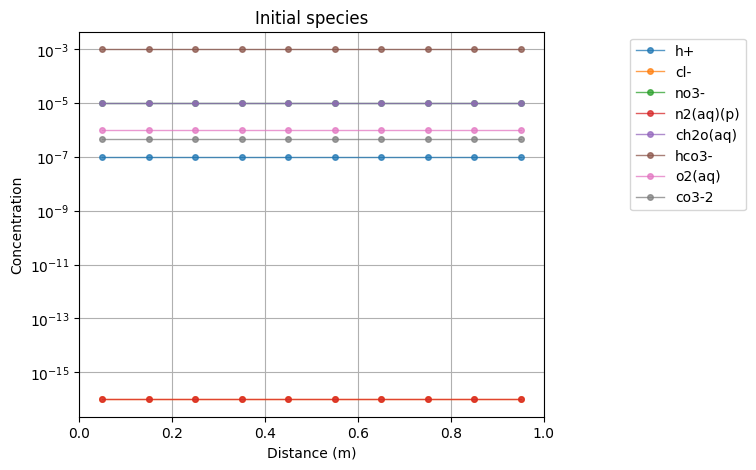

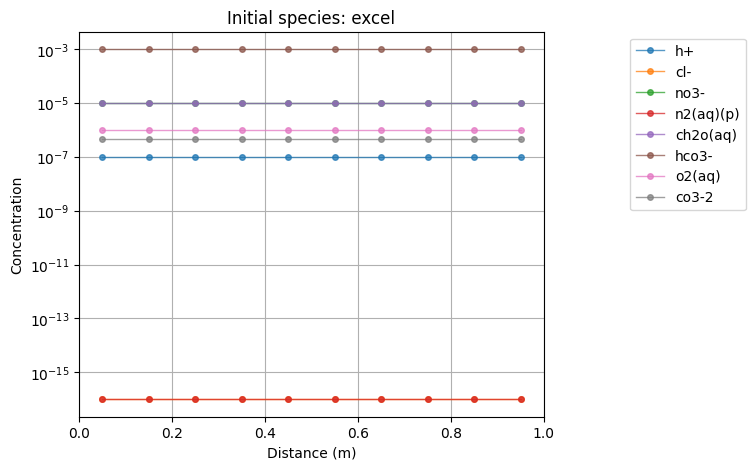

In [60]:
# Visualizamos las concentraciones de las especies en el paso inicial
plot.show_t(species["init_conc"], species["names"], x, y, z, f"Initial species", "log")
plot.show_t(s_excel[0], species["names"],x, y, z, f"Initial species: excel", "log")

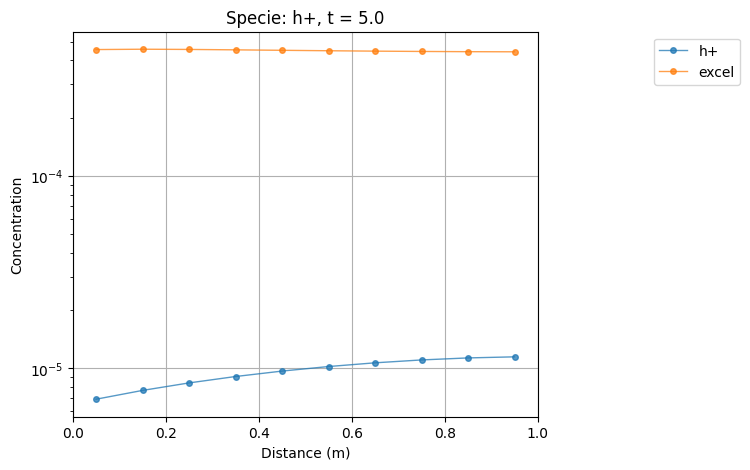

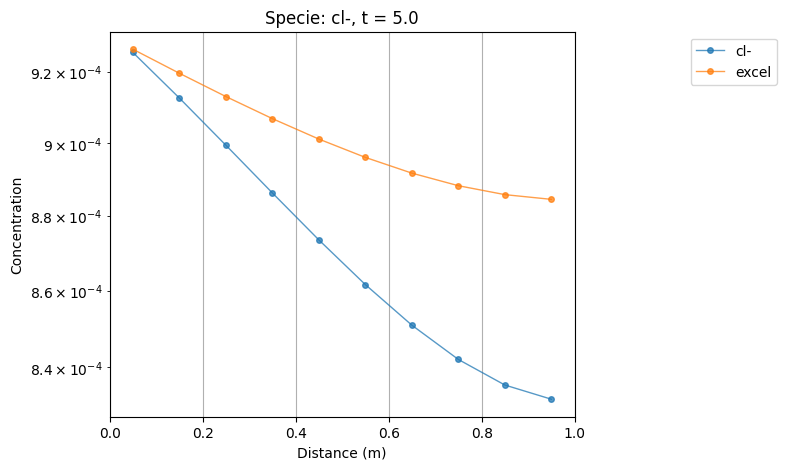

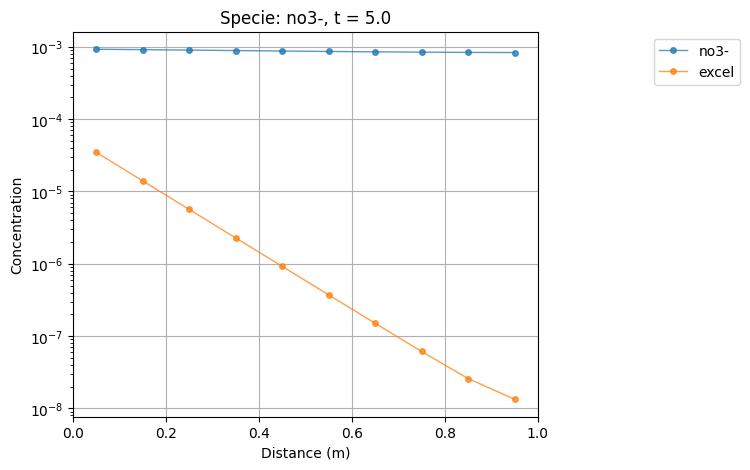

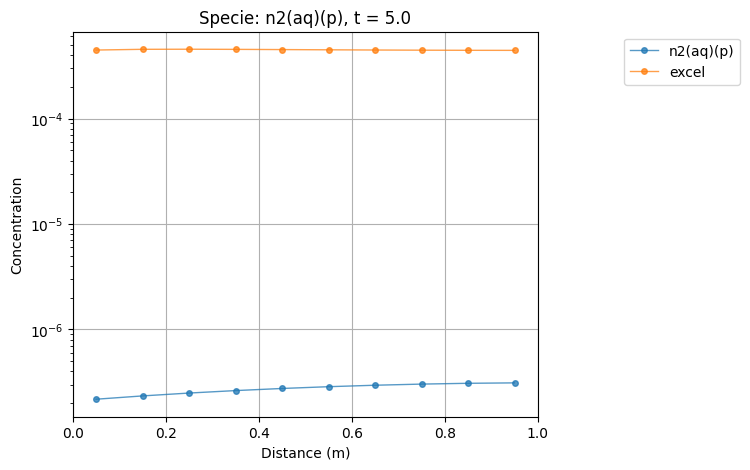

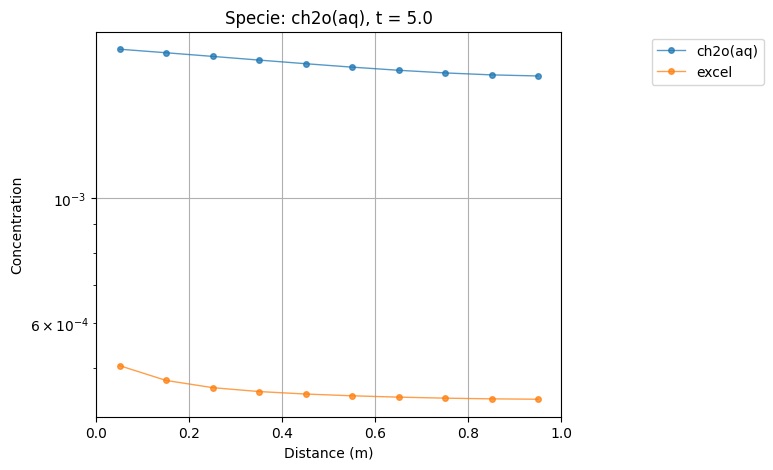

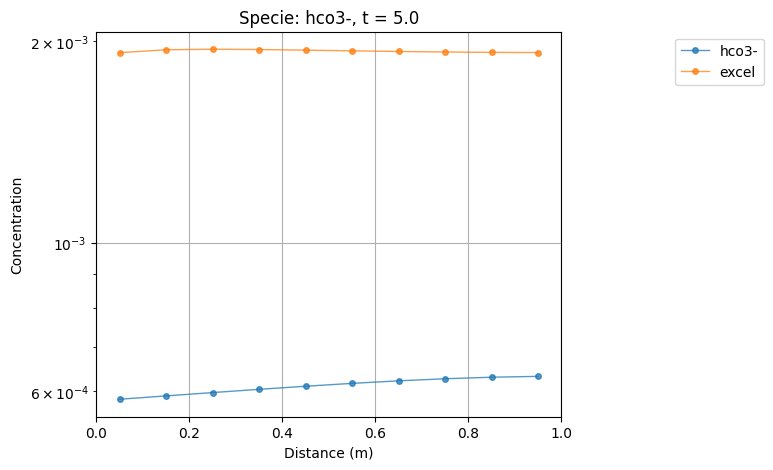

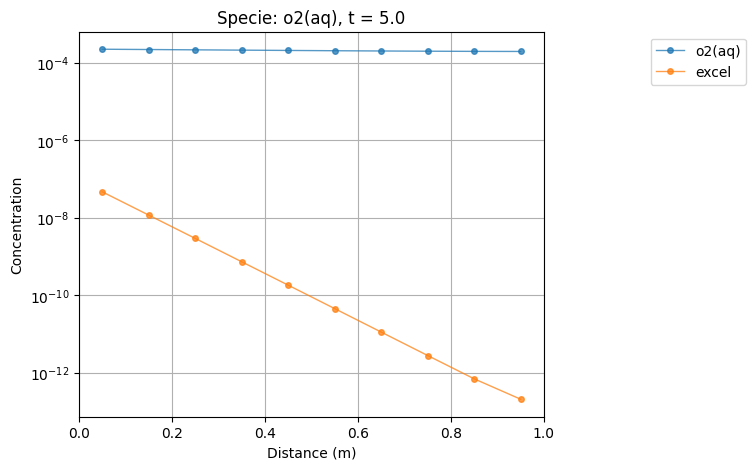

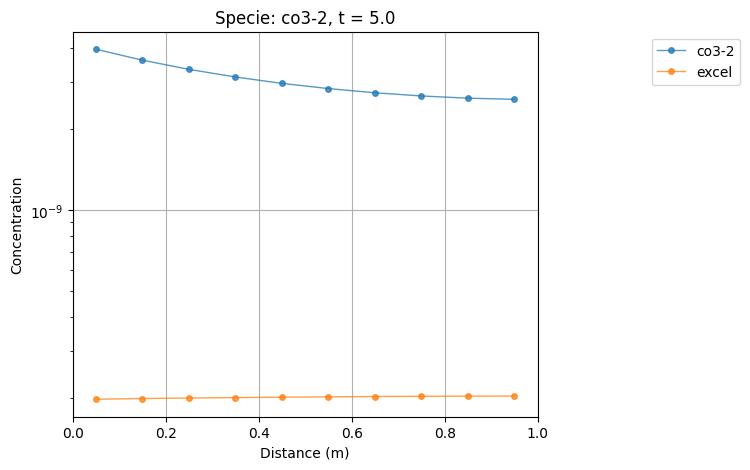

In [61]:
# Visualizamos las concetraciones de las especies en el paso NT
for c in range(0,8):
    plot.show_t([s_final[5.0][c], s_excel[5][c]], 
                [species["names"][c], "excel"],
                 x, y, z, f"Specie: {species["names"][c]}, t = {5.0}", "log")

In [54]:
#print("\n-> Writting final results:")
#with open("final_species.dat", "w") as f:
#    for k in s_final.keys():
#        for c in range(0,8):
#            l = [s for s in s_final[k][c].astype(str)]
#            l.insert(0, f"{k:4.2f}")
#            l.append("\n")
#            f.write(" ".join(l))


-> Writting final results:
